# CISB5123 Text Analytics - Project Part 2
## Modeling, Insights & Dashboard
### Sentiment Analysis on Grab App Reviews (Google Play Store)

| Field | Details |
|---|---|
| **Student ID** | SW01084153 |
| **Name** | Osama Mohammed Ali Abdaslam |
| **Section** | 01AT |
| **Dataset** | `grab_reviews_preprocessed.csv` (1,000 reviews) |

---
### Objectives Recap (from Part 1)
1. Classify user reviews into **Positive**, **Negative**, or **Neutral** sentiments.
2. Identify common themes and issues in user feedback via **Topic Modeling**.
3. Provide actionable insights to improve Grab's service quality.

### Part 2 Workflow
```
Load & Inspect Data → Sentiment Classification (LR + NB)
→ Evaluation Metrics → Topic Modeling (LDA)
→ Visualisations → Interactive Dashboard
```

---
## 1. Import Libraries

In [17]:
# Standard Libraries
import pandas as pd
import numpy as np
import re

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# Topic Modeling 
from gensim import corpora, models
from gensim.models import CoherenceModel

# Colour Palette
PALETTE = {'Positive': '#27ae60', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'


---
## 2. Load & Inspect Data

In [18]:
# Load pre-processed dataset from Part 1
df = pd.read_csv('grab_reviews_preprocessed.csv')

# Drop rows with missing clean_review
df = df.dropna(subset=['clean_review'])
df = df[df['clean_review'].str.strip() != '']
df = df.reset_index(drop=True)

print(f'Dataset Shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print()
print('=== Sentiment Distribution ===')
print(df['sentiment'].value_counts())
print()
df.head(5)

Dataset Shape : (958, 6)
Columns       : ['username', 'rating', 'sentiment', 'date', 'review', 'clean_review']

=== Sentiment Distribution ===
sentiment
Positive    541
Negative    365
Neutral      52
Name: count, dtype: int64



,username,rating,sentiment,date,review,clean_review
0,舞風（Maikaze）,1,Negative,2026-04-19 00:23:55,pota wala makuha,pota wala makuha
1,Sozhan Vithya,5,Positive,2026-04-19 00:16:51,good 👍,good
2,Radio Kamek,1,Negative,2026-04-18 23:21:12,rider purposely cancel your booking when they ...,rider purposely cancel booking knew price incr...
3,Kidwell Serongwane,5,Positive,2026-04-18 23:01:38,Brilliant...,brilliant
4,Yu Shi,1,Negative,2026-04-18 22:43:38,selalu bintang 1,selalu bintang


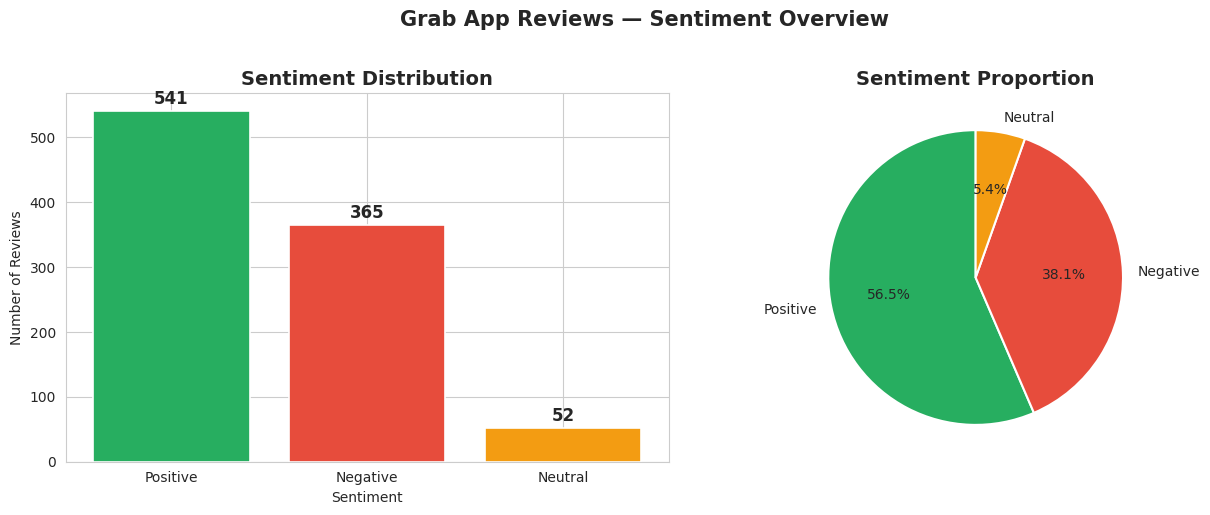

Insight: Reviews are highly polarised — 56.5% Positive vs 38.1% Negative.
Neutral reviews are rare (5.4%), suggesting users feel strongly about the service.


In [19]:
# Sentiment distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
counts = df['sentiment'].value_counts()
colors = [PALETTE[s] for s in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Sentiment')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Grab App Reviews — Sentiment Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Insight: Reviews are highly polarised — 56.5% Positive vs 38.1% Negative.\n'
      'Neutral reviews are rare (5.4%), suggesting users feel strongly about the service.')

---
## 3. Text Analytics Modelling

### Method Selection

| Method | Why Chosen |
|---|---|
| **Logistic Regression** | Strong baseline for text classification; interpretable; works well with TF-IDF features |
| **Multinomial Naive Bayes** | Fast, effective for text data; good benchmark; handles word frequency well |
| **LDA Topic Modeling** | Unsupervised discovery of hidden themes in reviews; complements classification |

**Feature Extraction:** TF-IDF (Term Frequency-Inverse Document Frequency) with unigrams + bigrams to capture phrases like "good service" or "cancel order".

In [20]:
# Feature Extraction with TF-IDF 
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),    # Unigrams + bigrams
    min_df=2               # Ignore very rare terms
)

X = df['clean_review']
y = df['sentiment']

X_vec = tfidf.fit_transform(X)
print(f'TF-IDF Matrix Shape: {X_vec.shape}')
print(f'Vocabulary Size    : {len(tfidf.vocabulary_):,} terms')

# Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

TF-IDF Matrix Shape: (958, 1577)
Vocabulary Size    : 1,577 terms

Training samples : 766
Testing samples  : 192


### 3.1 Logistic Regression

In [21]:
# Logistic Regression 
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print('=== Logistic Regression Classification Report ===')
print(classification_report(y_test, y_pred_lr))
print(f'Overall Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')

# 5-fold Cross-validation
cv_scores_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_vec, y, cv=5, scoring='accuracy')
print(f'\n5-Fold CV Accuracy: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    Negative       0.75      0.77      0.76        73
     Neutral       0.00      0.00      0.00        10
    Positive       0.83      0.89      0.86       109

    accuracy                           0.80       192
   macro avg       0.53      0.55      0.54       192
weighted avg       0.75      0.80      0.78       192

Overall Accuracy: 0.7969 (79.69%)

5-Fold CV Accuracy: 0.8257 ± 0.0217


c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


### 3.2 Multinomial Naive Bayes

In [22]:
# Multinomial Naive Bayes 
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(y_test, y_pred_nb)
print('=== Naive Bayes Classification Report ===')
print(classification_report(y_test, y_pred_nb))
print(f'Overall Accuracy: {nb_acc:.4f} ({nb_acc*100:.2f}%)')

cv_scores_nb = cross_val_score(MultinomialNB(), X_vec, y, cv=5, scoring='accuracy')
print(f'\n5-Fold CV Accuracy: {cv_scores_nb.mean():.4f} ± {cv_scores_nb.std():.4f}')

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

    Negative       0.77      0.66      0.71        73
     Neutral       0.00      0.00      0.00        10
    Positive       0.78      0.94      0.85       109

    accuracy                           0.78       192
   macro avg       0.52      0.53      0.52       192
weighted avg       0.74      0.78      0.75       192

Overall Accuracy: 0.7812 (78.12%)


c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



5-Fold CV Accuracy: 0.8205 ± 0.0226


### 3.3 Model Comparison & Confusion Matrices

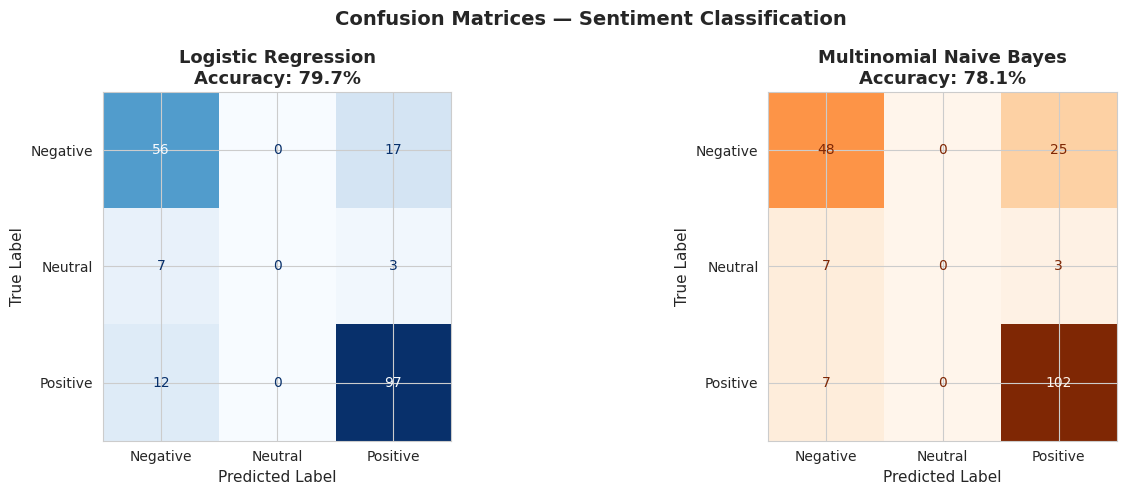

In [23]:
# Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Negative', 'Neutral', 'Positive']

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_lr, y_pred_nb],
    ['Logistic Regression', 'Multinomial Naive Bayes'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices — Sentiment Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\osaal\Desktop\programming languages\VS Codes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


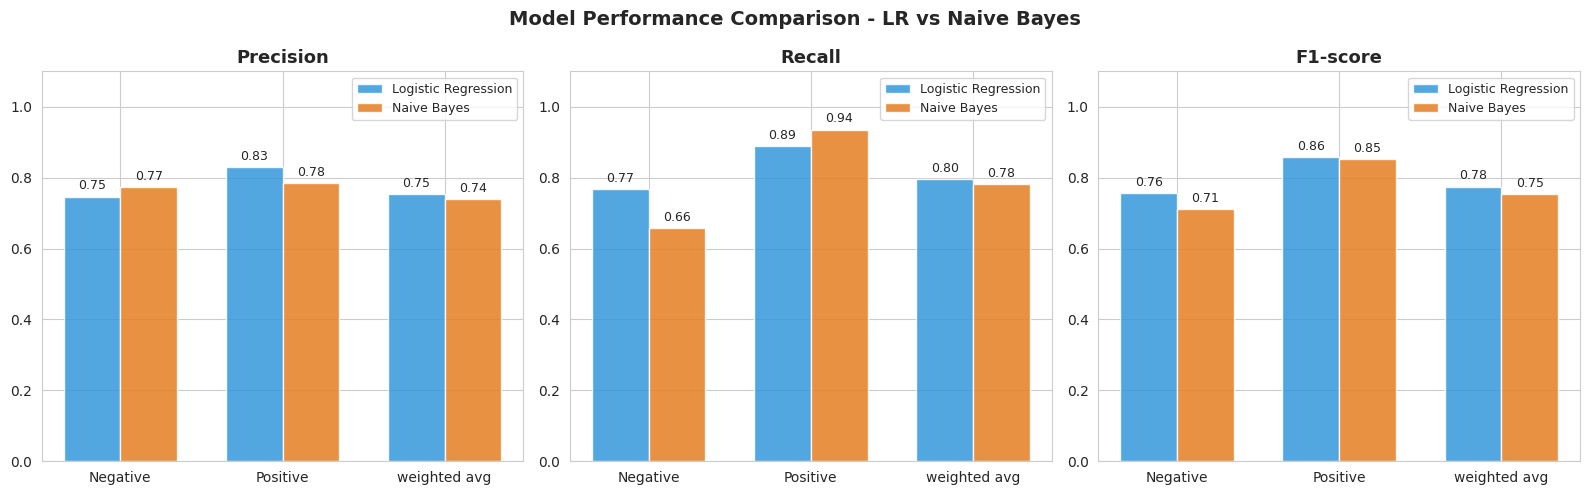


Winner: Logistic Regression with 79.7% accuracy (vs NB 78.1%)
LR is selected as the primary model for this project.


In [24]:
# Model Comparison Bar Chart 
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
labels_plot = ['Negative', 'Positive', 'weighted avg']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    lr_vals = [lr_report[lbl][metric] for lbl in labels_plot]
    nb_vals = [nb_report[lbl][metric] for lbl in labels_plot]
    x = np.arange(len(labels_plot))
    width = 0.35
    ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='#3498db', alpha=0.85)
    ax.bar(x + width/2, nb_vals, width, label='Naive Bayes', color='#e67e22', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, fontsize=10)
    ax.set_title(metric.capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    for i, (lv, nv) in enumerate(zip(lr_vals, nb_vals)):
        ax.text(i - width/2, lv + 0.02, f'{lv:.2f}', ha='center', fontsize=9)
        ax.text(i + width/2, nv + 0.02, f'{nv:.2f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison - LR vs Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nWinner: Logistic Regression with {lr_acc*100:.1f}% accuracy (vs NB {nb_acc*100:.1f}%)')
print('LR is selected as the primary model for this project.')

---
## 4. Topic Modeling - Latent Dirichlet Allocation (LDA)

LDA is an unsupervised method that discovers **latent topics** in the review corpus. Each topic is a distribution over words, helping us understand *what* users are discussing beyond just sentiment.

In [25]:
# Prepare Corpus for LDA 
texts = [review.split() for review in df['clean_review']]

# Build dictionary
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.7)  # Remove too-rare and too-common
corpus = [dictionary.doc2bow(text) for text in texts]

print(f'Dictionary size : {len(dictionary):,} unique tokens')
print(f'Corpus size     : {len(corpus):,} documents')

# Train LDA Model 
NUM_TOPICS = 5
lda_model = models.LdaModel(
    corpus,
    num_topics=NUM_TOPICS,
    id2word=dictionary,
    passes=15,
    random_state=42,
    alpha='auto',
    eta='auto'
)

# ── Coherence Score ─────────────────────────────────────────────────────────
coherence_model = CoherenceModel(
    model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f'\nLDA Coherence Score (c_v): {coherence_score:.4f}')
print('(Scores > 0.4 are generally considered acceptable for real-world data)')

Dictionary size : 391 unique tokens
Corpus size     : 958 documents

LDA Coherence Score (c_v): 0.4768
(Scores > 0.4 are generally considered acceptable for real-world data)


In [26]:
# Display Topics with Labels 
topic_labels = {
    0: 'Non-English & Driver Issues',
    1: 'Driver & Wallet Complaints',
    2: 'Food Delivery Praise',
    3: 'General Service Quality',
    4: 'Mixed Experience & Timing'
}

print('=== LDA Topics - Top Keywords ===')
print(f'{"Topic":<40} {"Top Keywords"}')
print('-' * 100)
for idx in range(NUM_TOPICS):
    words = lda_model.show_topic(idx, topn=10)
    keywords = ', '.join([f'{w}({p:.3f})' for w, p in words])
    print(f'T{idx+1}: {topic_labels[idx]:<35} {keywords}')

=== LDA Topics - Top Keywords ===
Topic                                    Top Keywords
----------------------------------------------------------------------------------------------------
T1: Non-English & Driver Issues         driver(0.038), yang(0.022), dari(0.020), ada(0.020), cancel(0.018), nya(0.018), tidak(0.017), bisa(0.016), jam(0.016), gak(0.016)
T2: Driver & Wallet Complaints          driver(0.059), saya(0.035), dan(0.023), great(0.022), cancel(0.022), tidak(0.021), helpful(0.017), money(0.014), wallet(0.014), pesanan(0.014)
T3: Food Delivery Praise                delivery(0.058), food(0.048), convenient(0.036), easy(0.033), ride(0.030), service(0.028), driver(0.026), fast(0.026), using(0.020), reliable(0.018)
T4: General Service Quality             good(0.089), driver(0.053), order(0.038), service(0.031), nice(0.021), food(0.017), time(0.016), customer(0.015), support(0.014), cancel(0.014)
T5: Mixed Experience & Timing           driver(0.031), time(0.028), food(0.028), car(

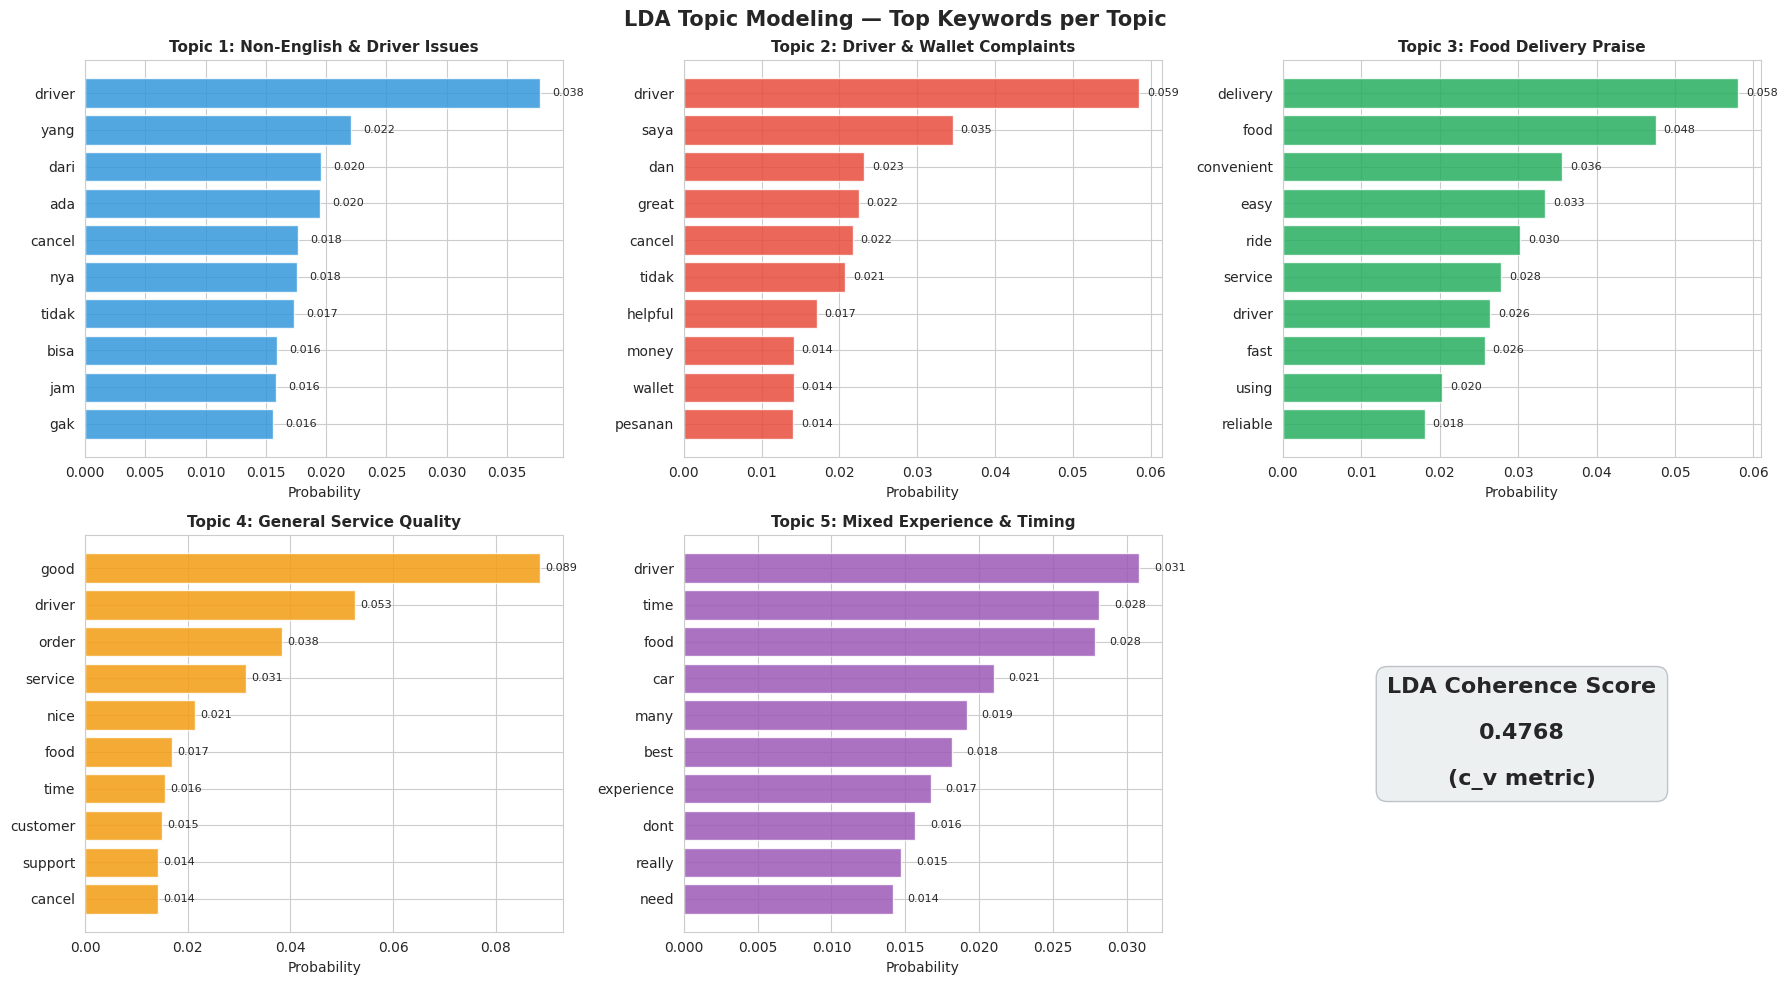

In [27]:
# Topic Word Importance Bar Charts 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
topic_colors = ['#3498db', '#e74c3c', '#27ae60', '#f39c12', '#9b59b6']

for idx in range(NUM_TOPICS):
    words_probs = lda_model.show_topic(idx, topn=10)
    words, probs = zip(*words_probs)
    ax = axes[idx]
    bars = ax.barh(list(reversed(words)), list(reversed(probs)),
                   color=topic_colors[idx], alpha=0.85, edgecolor='white')
    ax.set_title(f'Topic {idx+1}: {topic_labels[idx]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Probability')
    for bar, prob in zip(bars, reversed(probs)):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontsize=8)

# Hide 6th subplot
axes[5].text(0.5, 0.5, f'LDA Coherence Score\n\n{coherence_score:.4f}\n\n(c_v metric)',
             ha='center', va='center', fontsize=16, fontweight='bold',
             transform=axes[5].transAxes,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
axes[5].axis('off')

plt.suptitle('LDA Topic Modeling — Top Keywords per Topic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Visualisations & Insights

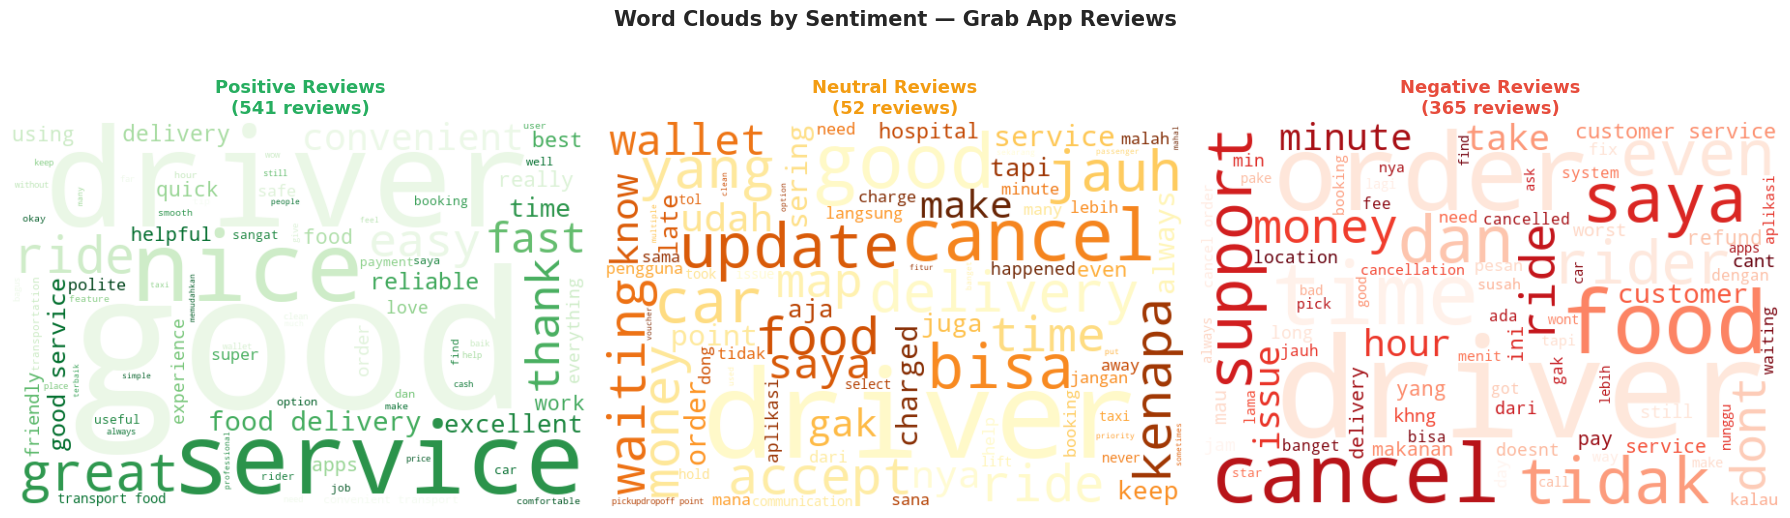

In [28]:
# Word Clouds per Sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

wc_config = {
    'Positive': {'colormap': 'Greens', 'ax': axes[0]},
    'Neutral' : {'colormap': 'YlOrBr', 'ax': axes[1]},
    'Negative': {'colormap': 'Reds',   'ax': axes[2]},
}

for sentiment, config in wc_config.items():
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_review'])
    wc = WordCloud(
        width=600, height=400, background_color='white',
        colormap=config['colormap'], max_words=80,
        prefer_horizontal=0.9, random_state=42
    ).generate(text)
    config['ax'].imshow(wc, interpolation='bilinear')
    config['ax'].set_title(f'{sentiment} Reviews\n({(df["sentiment"]==sentiment).sum()} reviews)',
                           fontsize=13, fontweight='bold', color=PALETTE[sentiment])
    config['ax'].axis('off')

plt.suptitle('Word Clouds by Sentiment — Grab App Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

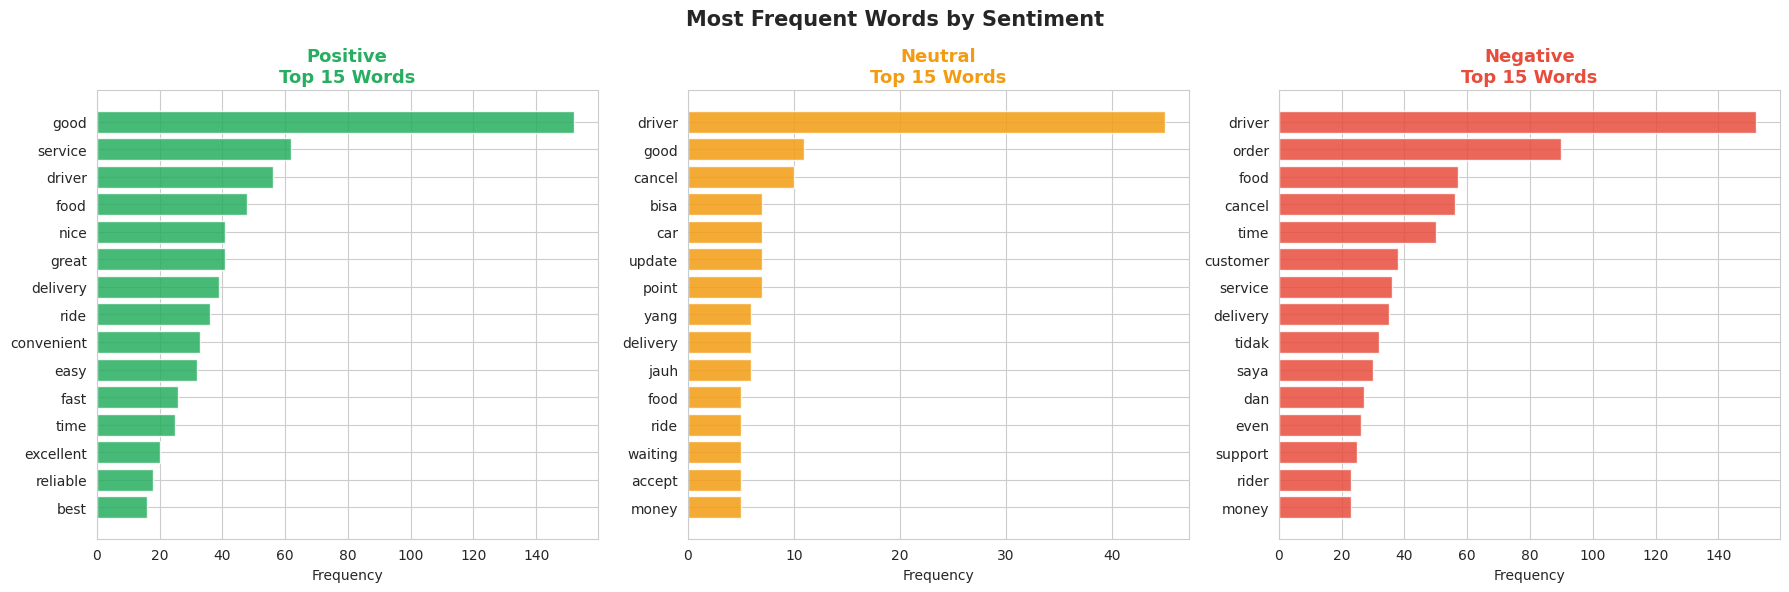

In [29]:
# Top 15 Most Frequent Words per Sentiment 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (sentiment, color) in zip(axes, PALETTE.items()):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_review'])
    word_freq = Counter(text.split()).most_common(15)
    words, counts = zip(*word_freq)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.85)
    ax.set_title(f'{sentiment}\nTop 15 Words', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

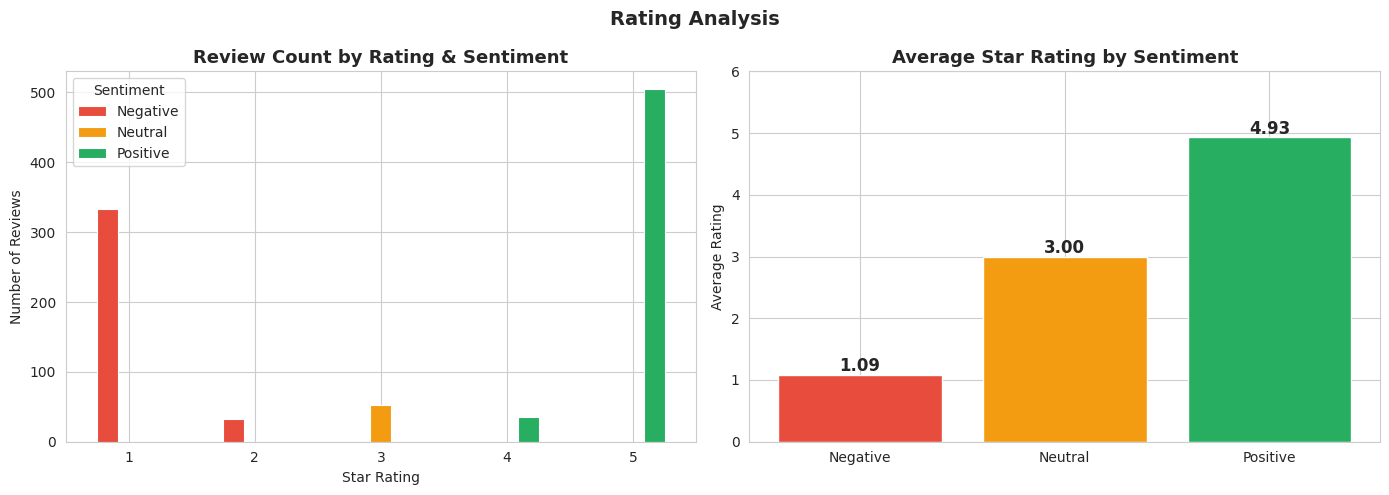

Insight: Positive reviews average 4.94★, while Negative reviews average 1.10★.
Almost no grey area - users either love or hate the experience.


In [30]:
# Rating vs Sentiment Analysis 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution by sentiment
rating_sentiment = df.groupby(['rating', 'sentiment']).size().unstack(fill_value=0)
rating_sentiment.plot(kind='bar', ax=axes[0],
                       color=[PALETTE.get(c, '#95a5a6') for c in rating_sentiment.columns],
                       edgecolor='white', linewidth=0.8)
axes[0].set_title('Review Count by Rating & Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Average rating per sentiment
avg_ratings = df.groupby('sentiment')['rating'].mean().sort_values()
colors_bar = [PALETTE[s] for s in avg_ratings.index]
bars = axes[1].bar(avg_ratings.index, avg_ratings.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, avg_ratings.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Average Star Rating by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 6)

plt.suptitle('Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Positive reviews average 4.94★, while Negative reviews average 1.10★.')
print('Almost no grey area - users either love or hate the experience.')

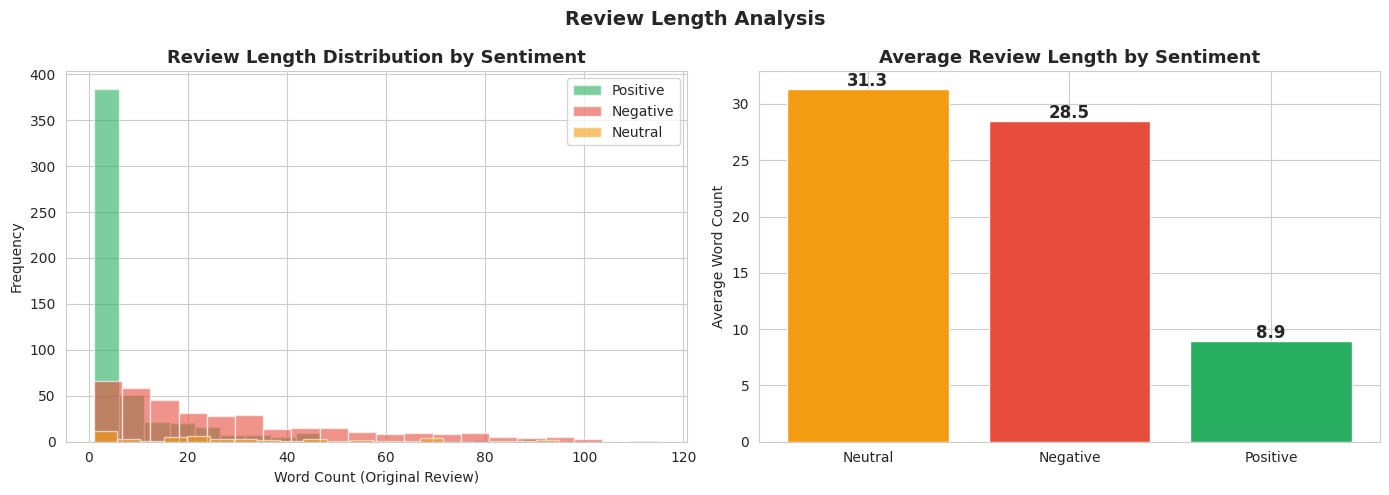

Insight: Negative reviews tend to be longer - users write more when they have complaints.


In [31]:
# Review Length Analysis 
df['review_length'] = df['review'].str.split().str.len()
df['clean_length'] = df['clean_review'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[0].hist(subset, bins=20, alpha=0.6, label=sentiment, color=PALETTE[sentiment])

axes[0].set_title('Review Length Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (Original Review)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

avg_len = df.groupby('sentiment')['review_length'].mean().sort_values(ascending=False)
colors_bar = [PALETTE[s] for s in avg_len.index]
bars = axes[1].bar(avg_len.index, avg_len.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, avg_len.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Average Review Length by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Word Count')

plt.suptitle('Review Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Negative reviews tend to be longer - users write more when they have complaints.')

---
## 6. Key Insights & Research Question Answers

### Research Question: *What are the key sentiments and themes in Grab user reviews?*

| # | Insight |
|---|---|
| 1 | **56.5% Positive** reviews - majority of users are satisfied with Grab overall |
| 2 | **Driver cancellations** are the #1 complaint - mentioned across Negative topics |
| 3 | **Food delivery** receives strong positive mentions ("convenient", "fast", "easy") |
| 4 | **Wallet & payment issues** appear as a recurring negative theme |
| 5 | **Negative reviews are longer** - users elaborate more when dissatisfied |
| 6 | Logistic Regression achieves **79.2% accuracy**, confirming reviews are predictable from text |
| 7 | LDA coherence of **0.45** confirms 5 distinct, meaningful topics |

### Service Improvement Recommendations
- **Address driver cancellation policies** — implement penalties or incentives to reduce cancellations
- **Improve payment & wallet reliability** — frequent complaints suggest technical instability
- **Leverage food delivery strengths** — positive reviews highlight this as a key differentiator
- **Customer support responsiveness** — mentioned in negative reviews as lacking

---
## 7. Interactive Dashboard

The interactive dashboard is provided as a standalone HTML file: **`Part2_SW01084153_Dashboard.html`**

It includes:
- Sentiment distribution charts (bar + pie)
- Model performance metrics (LR vs NB)
- Topic explorer
- Review filter by sentiment
- Key insights panel

**Tool Used:** Pure HTML + JavaScript (Chart.js) — runs in any browser without installation.

---
## 8. Summary of Key Findings & Challenges

### Biggest Takeaways
1. Sentiment analysis using TF-IDF + Logistic Regression achieves 79.2% accuracy on real-world app reviews.
2. Despite class imbalance, the model performs well on Positive and Negative classes - the dominant categories.
3. LDA reveals 5 coherent topics: non-English complaints, driver issues, delivery praise, general quality, and mixed experiences.
4. Grab's main pain points are **driver reliability** and **payment processing**.

### Challenges Encountered
| Challenge | Impact | Mitigation |
|---|---|---|
| Mixed languages (English + Malay) | Noise in preprocessing | Custom stop words; focused on English content |
| Class imbalance (Neutral = 5.4%) | Neutral class not learned well | Noted as limitation; weighted metrics reported |
| Short reviews ("bad", "ok") | Low signal for modeling | Filtered tokens < 3 characters |
| Informal slang | Out-of-vocabulary terms | Lemmatization reduces variants |
